# Notebook 4: Modelo de referencia SARIMA

Este notebook implementa un modelo SARIMA (Seasonal AutoRegressive 
Integrated Moving Average) que servirá como **modelo de referencia** 
frente al modelo principal Prophet desarrollado en el notebook 3.

El objetivo no es construir el modelo con mejor rendimiento posible, 
sino disponer de un punto de comparación basado en una técnica 
estadística clásica ampliamente utilizada en el análisis de series 
temporales. Esto permite contextualizar los resultados de Prophet 
frente a una alternativa establecida.

A diferencia del notebook 3, donde se exploraron diversas variantes 
del modelo con regresores externos, en este notebook se trabajará con 
SARIMA en su forma más sencilla: solo la serie temporal de pedidos, 
sin variables exógenas. Esta simplificación es deliberada por dos 
razones:

- SARIMA puro es la implementación clásica del modelo y la referencia 
  más reconocida en la literatura de series temporales.
- La comparativa entre un modelo simple (SARIMA) y un modelo más 
  completo (Prophet con regresores y festivos) refleja con mayor 
  claridad el valor añadido del enfoque moderno.

La metodología de evaluación será la misma que en el notebook 3 
(división cronológica con conjunto de test reservado y validación 
cruzada temporal), garantizando que las métricas sean directamente 
comparables.

## 1. Configuración inicial

Se importan las librerías necesarias y se carga el dataset 
enriquecido generado en el notebook 2.

In [18]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from pathlib import Path

# Suprimimos warnings de convergencia de modelos estadísticos
# para mantener limpia la salida
warnings.filterwarnings("ignore")

# Configuración de matplotlib para gráficas con estilo coherente
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 2. Carga del dataset

Se carga el dataset enriquecido. SARIMA solo necesita la serie 
temporal de pedidos (sin regresores), pero se carga el dataset 
completo para mantener coherencia con los demás notebooks y poder 
acceder a los festivos en caso de querer ampliar el modelo más 
adelante.

In [19]:
# Cargamos el dataset enriquecido generado en el notebook 2
df = pd.read_csv(
    "../data/processed/dataset_enriquecido.csv",
    parse_dates=["fecha"]
)

# Inspección básica
print(f"Total de días: {len(df):,}")
print(f"Rango temporal: {df['fecha'].min().date()} a {df['fecha'].max().date()}")
print(f"\nPrimeras filas:")
print(df.head())

Total de días: 1,067
Rango temporal: 2016-09-01 a 2019-08-03

Primeras filas:
       fecha  n_pedidos  es_festivo festivo_nombre  temp_media_dia  \
0 2016-09-01         13           0            NaN           17.42   
1 2016-09-02         28           0            NaN           17.14   
2 2016-09-03         52           0            NaN           16.83   
3 2016-09-04         21           0            NaN           17.96   
4 2016-09-05          9           0            NaN           17.86   

   precipitacion_total_dia  viento_medio_dia  humedad_media_dia  \
0                      0.0              9.65              73.38   
1                      1.3             14.96              82.58   
2                      2.8             17.54              81.54   
3                      0.6             20.36              75.00   
4                      2.4              9.07              87.17   

   nubosidad_media_dia  temp_media_serv  precipitacion_total_serv  \
0                68.83       

## 3. Análisis exploratorio de la serie

Antes de aplicar SARIMA, es necesario analizar las propiedades 
estadísticas de la serie temporal de pedidos. Concretamente:

- **Estacionariedad**: SARIMA asume que la serie de entrada (o su 
  diferenciación) es estacionaria, es decir, que sus propiedades 
  estadísticas no varían sistemáticamente con el tiempo. Una serie 
  con tendencia clara o cambios de varianza no es estacionaria y 
  requiere transformaciones previas.

- **Estacionalidad**: el componente estacional de SARIMA requiere 
  que se identifique el periodo de los patrones recurrentes. En el 
  caso de los pedidos diarios, el patrón semanal (S=7) es el más 
  evidente.

### 3.1. Visualización de la serie completa

Una primera inspección visual permite identificar de forma 
cualitativa los patrones presentes en la serie.

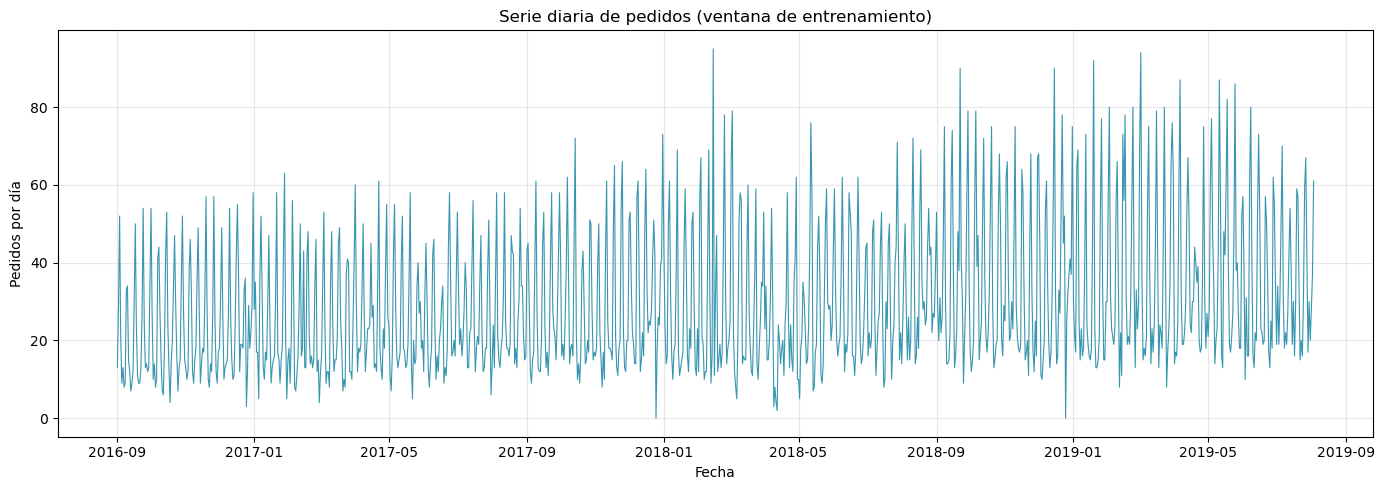

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["fecha"], df["n_pedidos"], color="#3896b0", linewidth=0.8)
ax.set_title("Serie diaria de pedidos (ventana de entrenamiento)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
plt.tight_layout()
plt.show()

### 3.2. Test estadístico de estacionariedad

El test de **Dickey-Fuller aumentado** (ADF) es el contraste estándar 
para evaluar la estacionariedad de una serie temporal. La hipótesis 
nula del test es que la serie tiene una raíz unitaria (es decir, que 
**no es estacionaria**). Si el p-valor del test es inferior a 0,05, se 
rechaza la hipótesis nula y se considera la serie estacionaria.

In [21]:
from statsmodels.tsa.stattools import adfuller

# Aplicamos el test ADF sobre la serie original
resultado = adfuller(df["n_pedidos"])

# Mostramos los resultados de forma legible
print("Test de Dickey-Fuller aumentado (ADF)")
print("=" * 50)
print(f"Estadístico ADF:  {resultado[0]:.4f}")
print(f"p-valor:          {resultado[1]:.6f}")
print(f"Lags utilizados:  {resultado[2]}")
print(f"Observaciones:    {resultado[3]}")
print(f"\nValores críticos:")
for clave, valor in resultado[4].items():
    print(f"  {clave}: {valor:.4f}")
print()
if resultado[1] < 0.05:
    print("Conclusión: se rechaza la hipótesis nula.")
    print("La serie es estacionaria (no requiere diferenciación).")
else:
    print("Conclusión: NO se rechaza la hipótesis nula.")
    print("La serie NO es estacionaria (requiere diferenciación).")

Test de Dickey-Fuller aumentado (ADF)
Estadístico ADF:  -2.4844
p-valor:          0.119305
Lags utilizados:  20
Observaciones:    1046

Valores críticos:
  1%: -3.4366
  5%: -2.8643
  10%: -2.5682

Conclusión: NO se rechaza la hipótesis nula.
La serie NO es estacionaria (requiere diferenciación).


### 3.3. Diferenciación de la serie

Como la serie original no es estacionaria, se aplica una 
**diferenciación de primer orden**: en lugar de modelar el valor 
absoluto de pedidos cada día, se modela la diferencia entre el día 
actual y el día anterior. Esta transformación elimina la tendencia 
de la serie y permite trabajar con la variación diaria, que es 
estacionaria en la mayoría de los casos.

Si la serie diferenciada resulta estacionaria, se confirmará que el 
parámetro `d` del modelo SARIMA debe ser igual a 1.

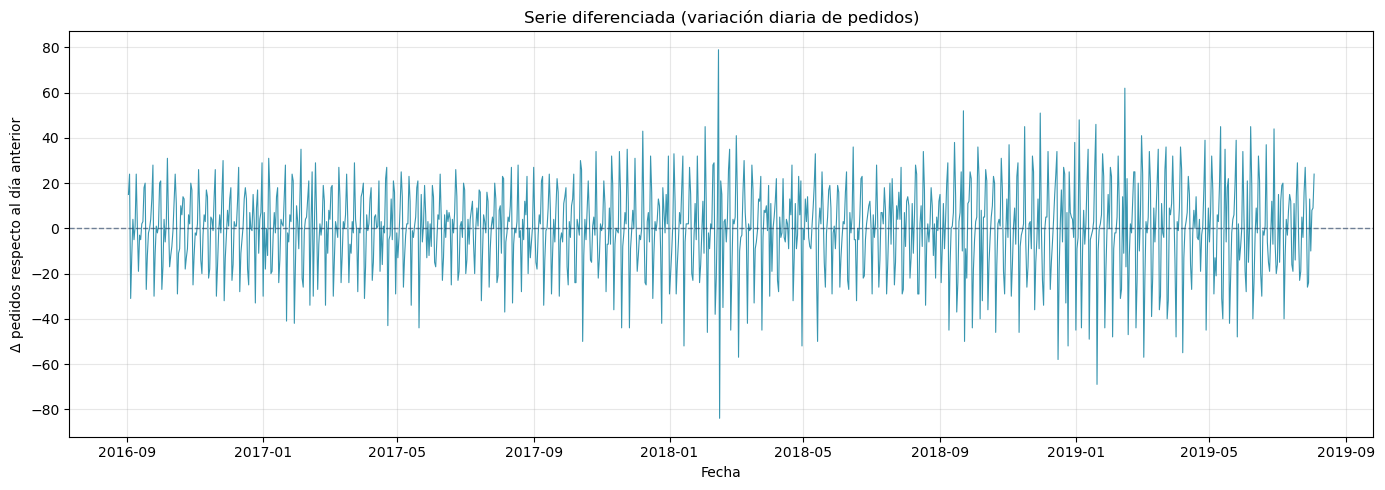

Test de Dickey-Fuller aumentado (ADF) sobre serie diferenciada
Estadístico ADF:  -14.3299
p-valor:          0.000000

Valores críticos:
  1%: -3.4366
  5%: -2.8643
  10%: -2.5682

Conclusión: se rechaza la hipótesis nula.
La serie diferenciada es estacionaria. Por tanto d=1.


In [22]:
# Aplicamos diferenciación de primer orden
serie_diferenciada = df["n_pedidos"].diff().dropna()

# Visualización de la serie diferenciada
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["fecha"].iloc[1:], serie_diferenciada, 
        color="#3896b0", linewidth=0.8)
ax.set_title("Serie diferenciada (variación diaria de pedidos)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Δ pedidos respecto al día anterior")
ax.axhline(y=0, color="#1f3a5f", linestyle="--", linewidth=1, alpha=0.6)
plt.tight_layout()
plt.show()

# Test de Dickey-Fuller sobre la serie diferenciada
resultado_dif = adfuller(serie_diferenciada)

print("Test de Dickey-Fuller aumentado (ADF) sobre serie diferenciada")
print("=" * 60)
print(f"Estadístico ADF:  {resultado_dif[0]:.4f}")
print(f"p-valor:          {resultado_dif[1]:.6f}")
print(f"\nValores críticos:")
for clave, valor in resultado_dif[4].items():
    print(f"  {clave}: {valor:.4f}")
print()
if resultado_dif[1] < 0.05:
    print("Conclusión: se rechaza la hipótesis nula.")
    print("La serie diferenciada es estacionaria. Por tanto d=1.")
else:
    print("Conclusión: la serie diferenciada sigue sin ser estacionaria.")
    print("Conviene diferenciar una segunda vez (d=2).")

### 3.4. Análisis de autocorrelación

Las funciones de autocorrelación (ACF) y autocorrelación parcial 
(PACF) permiten identificar la estructura temporal de la serie y 
orientar la selección de los parámetros del modelo SARIMA. La ACF 
mide la correlación de la serie con sus propios valores rezagados a 
distintos retardos, mientras que la PACF aísla la correlación en cada 
retardo eliminando el efecto de los retardos intermedios.

Para series con estacionalidad semanal, los gráficos ACF y PACF 
muestran picos significativos en los retardos múltiplos del periodo 
estacional (7, 14, 21, etc.), lo que confirma visualmente la 
presencia del patrón.

Los gráficos se construyen sobre la serie diferenciada (d=1), no 
sobre la serie original, ya que el análisis de autocorrelación 
asume estacionariedad.

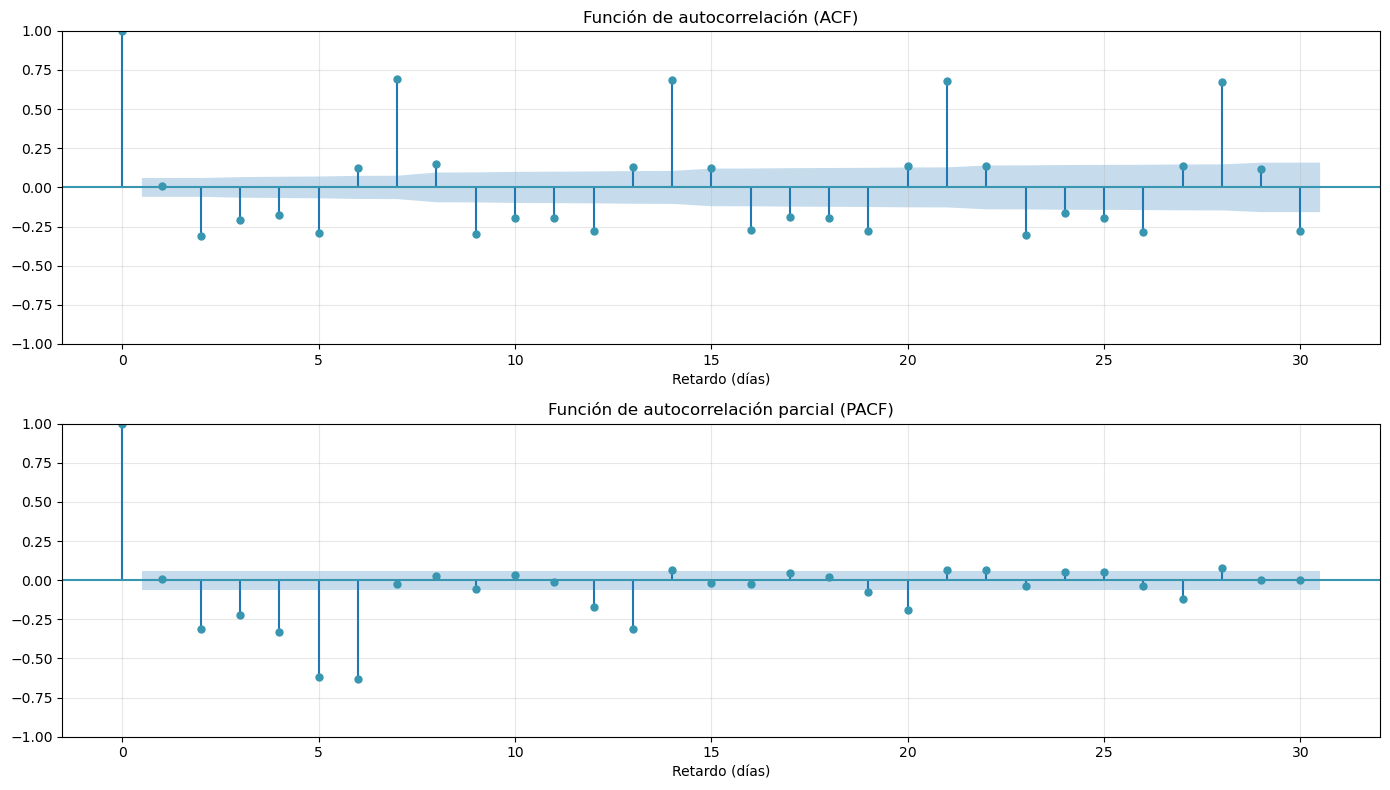

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Configuramos la figura con dos paneles (ACF y PACF)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ACF sobre la serie diferenciada, hasta 30 lags
plot_acf(serie_diferenciada, lags=30, ax=axes[0], color="#3896b0")
axes[0].set_title("Función de autocorrelación (ACF)")
axes[0].set_xlabel("Retardo (días)")

# PACF sobre la serie diferenciada, hasta 30 lags
plot_pacf(serie_diferenciada, lags=30, ax=axes[1], color="#3896b0", method="ywm")
axes[1].set_title("Función de autocorrelación parcial (PACF)")
axes[1].set_xlabel("Retardo (días)")

plt.tight_layout()
plt.show()

## 4. Selección automática de parámetros con auto_arima

Una vez confirmadas las propiedades de la serie (no estacionaria, 
con d=1 tras una diferenciación, y con estacionalidad semanal S=7), 
se utiliza la función `auto_arima` de la librería `pmdarima` para 
identificar la combinación óptima de parámetros (p, q, P, Q) según 
el **criterio de información de Akaike** (AIC). Este criterio 
penaliza la complejidad del modelo, evitando que se elija un modelo 
sobreajustado por incluir demasiados parámetros.

La búsqueda se restringe a los siguientes rangos por motivos de 
eficiencia computacional:

- **p, q (componente diaria):** entre 0 y 3.
- **P, Q (componente estacional):** entre 0 y 2.
- **d, D:** fijados a 1 según el análisis previo (d=1 confirmado por 
  el test ADF, D=1 habitual en series con patrón estacional fuerte).
- **S (periodo estacional):** 7 (semanal).

Para evaluar de forma realista los modelos candidatos, la búsqueda 
se realiza sobre el conjunto de entrenamiento (todos los datos 
salvo los últimos 90 días, que se reservan como conjunto de test 
final).

In [24]:
from pmdarima import auto_arima

# Reservamos los últimos 90 días como conjunto de test final
n_test = 90
train = df["n_pedidos"].iloc[:-n_test]
test = df["n_pedidos"].iloc[-n_test:]

print(f"Tamaño del conjunto de entrenamiento: {len(train)} días")
print(f"Tamaño del conjunto de test: {len(test)} días")
print(f"\nIniciando búsqueda automática de parámetros...")
print()

# Búsqueda automática con auto_arima
modelo_auto = auto_arima(
    train,
    seasonal=True,
    m=7,                    # Periodo estacional semanal
    d=1,                    # Diferenciación regular fijada (test ADF)
    D=1,                    # Diferenciación estacional
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    information_criterion="aic",
    stepwise=True,          # Búsqueda inteligente más rápida
    suppress_warnings=True,
    error_action="ignore",
    trace=True              # Muestra los modelos probados
)

print()
print("=" * 60)
print("Mejor modelo encontrado:")
print(modelo_auto.summary())

Tamaño del conjunto de entrenamiento: 977 días
Tamaño del conjunto de test: 90 días

Iniciando búsqueda automática de parámetros...

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=8028.195, Time=0.13 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=7599.429, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=inf, Time=0.30 sec
 ARIMA(1,1,0)(0,1,0)[7]             : AIC=7844.122, Time=0.05 sec
 ARIMA(1,1,0)(2,1,0)[7]             : AIC=7490.190, Time=0.23 sec
 ARIMA(1,1,0)(2,1,1)[7]             : AIC=inf, Time=0.73 sec
 ARIMA(1,1,0)(1,1,1)[7]             : AIC=inf, Time=0.47 sec
 ARIMA(0,1,0)(2,1,0)[7]             : AIC=7660.949, Time=0.23 sec
 ARIMA(2,1,0)(2,1,0)[7]             : AIC=7410.225, Time=0.30 sec
 ARIMA(2,1,0)(1,1,0)[7]             : AIC=7509.211, Time=0.20 sec
 ARIMA(2,1,0)(2,1,1)[7]             : AIC=inf, Time=0.85 sec
 ARIMA(2,1,0)(1,1,1)[7]             : AIC=inf, Time=0.65 sec
 ARIMA(3,1,0)(2,1,0)[7]             : AIC=7327.156, Time=

## 5. Evaluación del modelo sobre el conjunto de test

Con el modelo SARIMA seleccionado, se procede a evaluar su capacidad 
predictiva sobre el conjunto de test reservado (los últimos 90 días 
del histórico). Para que la comparativa con Prophet sea directa, se 
utilizan las mismas métricas (MAE, RMSE, MAPE) y el mismo conjunto 
de test.

In [25]:
# Generamos predicciones sobre los 90 días de test
predicciones_test, intervalos_test = modelo_auto.predict(
    n_periods=n_test,
    return_conf_int=True,
    alpha=0.05  # intervalo de confianza al 95%
)

# Calculamos las métricas
mae = np.abs(test.values - predicciones_test).mean()
rmse = np.sqrt(((test.values - predicciones_test) ** 2).mean())
mape = (np.abs((test.values - predicciones_test) / test.values).mean()) * 100

print("Métricas del modelo SARIMA sobre el conjunto de test")
print("=" * 50)
print(f"MAE:    {mae:.2f} pedidos")
print(f"RMSE:   {rmse:.2f} pedidos")
print(f"MAPE:   {mape:.2f}%")
print(f"\n(Conjunto de test: últimos {n_test} días, "
      f"de {df['fecha'].iloc[-n_test].date()} "
      f"a {df['fecha'].iloc[-1].date()})")

Métricas del modelo SARIMA sobre el conjunto de test
MAE:    48.20 pedidos
RMSE:   54.33 pedidos
MAPE:   187.73%

(Conjunto de test: últimos 90 días, de 2019-05-06 a 2019-08-03)


### 5.1. Visualización de la predicción

Para inspeccionar visualmente la calidad del ajuste se representa la 
serie real frente a las predicciones del modelo, junto con el 
intervalo de confianza al 95%.

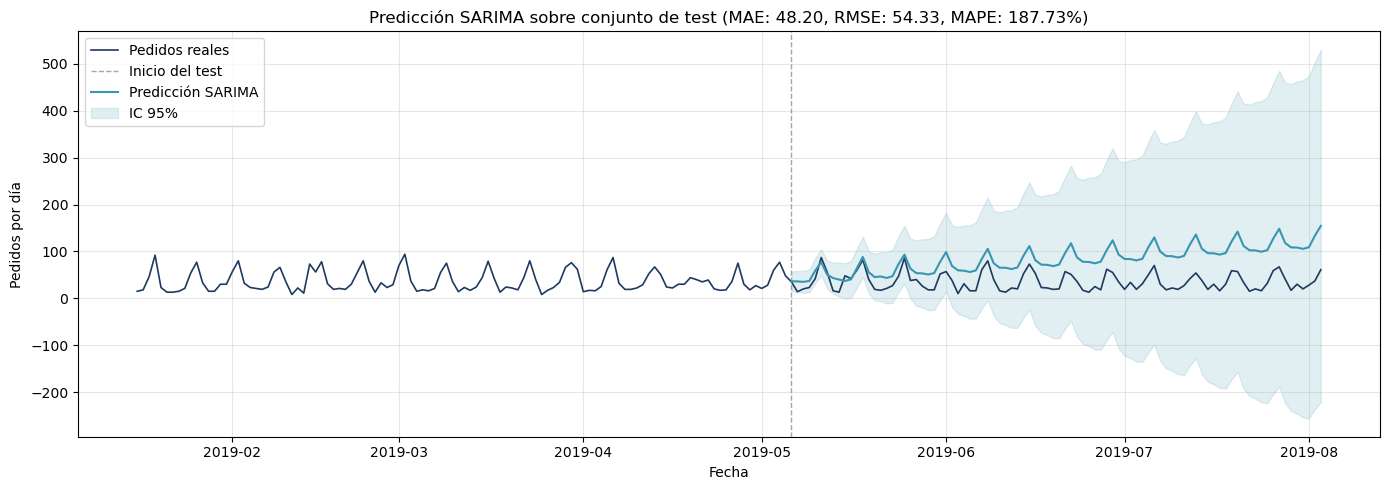

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))

# Serie real (últimos 200 días para contexto)
contexto_dias = 200
fechas_contexto = df["fecha"].iloc[-contexto_dias:]
valores_contexto = df["n_pedidos"].iloc[-contexto_dias:]
ax.plot(fechas_contexto, valores_contexto, 
        color="#1f3a5f", linewidth=1.2, label="Pedidos reales")

# Línea vertical separando entrenamiento y test
fecha_corte = df["fecha"].iloc[-n_test]
ax.axvline(x=fecha_corte, color="gray", linestyle="--", 
           linewidth=1, alpha=0.7, label="Inicio del test")

# Predicciones SARIMA sobre el test
fechas_test = df["fecha"].iloc[-n_test:]
ax.plot(fechas_test, predicciones_test, 
        color="#3896b0", linewidth=1.5, label="Predicción SARIMA")

# Intervalo de confianza
ax.fill_between(fechas_test, intervalos_test[:, 0], intervalos_test[:, 1],
                color="#3896b0", alpha=0.15, label="IC 95%")

ax.set_title(f"Predicción SARIMA sobre conjunto de test "
             f"(MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}%)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ruta_figura = Path("../docs/figura_sarima_test_unico.png")
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

## 6. Validación cruzada temporal

La evaluación sobre el conjunto de test único, con un horizonte de 
90 días, ha mostrado una degradación muy importante de la calidad 
predictiva (MAE 48,20, MAPE 187,73%). Esta degradación es esperable 
para un modelo SARIMA: a diferencia de Prophet, que descompone la 
serie en componentes explícitas de tendencia, estacionalidad y 
festivos, SARIMA reconstruye la predicción exclusivamente a partir 
de las dependencias temporales locales recientes, lo que limita 
fuertemente su capacidad predictiva en horizontes largos.

Para realizar una comparación justa con Prophet, se aplica 
validación cruzada temporal con los mismos dos horizontes que se 
utilizaron en el notebook 3:

- **Escenario corto plazo (14 días):** comparable con el modelo de 
  corto plazo de Prophet.
- **Escenario medio plazo (30 días):** comparable con el modelo de 
  medio plazo de Prophet.

La validación cruzada se realiza con la misma configuración: ventana 
inicial de entrenamiento de 548 días y nuevos cortes cada 90 días, 
generando 6 folds en cada escenario.

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def validacion_cruzada_sarima(serie, p, d, q, P, D, Q, s,
                                initial_size, period, horizon):
    """
    Validación cruzada temporal manual para SARIMA.
    
    Parámetros:
    - serie: serie temporal completa.
    - (p, d, q, P, D, Q, s): parámetros del modelo SARIMA.
    - initial_size: tamaño inicial del conjunto de entrenamiento.
    - period: días entre cortes consecutivos.
    - horizon: horizonte de predicción de cada fold.
    
    Devuelve un DataFrame con las métricas por fold y el promedio.
    """
    from pmdarima import ARIMA
    
    resultados = []
    fold = 1
    inicio_test = initial_size
    
    while inicio_test + horizon <= len(serie):
        train_fold = serie.iloc[:inicio_test]
        test_fold = serie.iloc[inicio_test:inicio_test + horizon]
        
        # Entrenamos el modelo con los parámetros ya seleccionados
        modelo = ARIMA(
            order=(p, d, q),
            seasonal_order=(P, D, Q, s),
            suppress_warnings=True
        )
        modelo.fit(train_fold)
        
        # Predicción sobre el horizonte
        prediccion = modelo.predict(n_periods=horizon)
        
        # Métricas del fold
        mae = mean_absolute_error(test_fold, prediccion)
        rmse = np.sqrt(mean_squared_error(test_fold, prediccion))
        mape = np.mean(np.abs((test_fold.values - prediccion) / test_fold.values)) * 100
        
        resultados.append({
            "fold": fold,
            "inicio_test": serie.index[inicio_test] if hasattr(serie.index, "date") else inicio_test,
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape
        })
        
        fold += 1
        inicio_test += period
    
    df_resultados = pd.DataFrame(resultados)
    
    # Promedios
    promedio = pd.DataFrame([{
        "fold": "Promedio",
        "inicio_test": "-",
        "MAE": df_resultados["MAE"].mean(),
        "RMSE": df_resultados["RMSE"].mean(),
        "MAPE": df_resultados["MAPE"].mean()
    }])
    
    return pd.concat([df_resultados, promedio], ignore_index=True)


# Parámetros del modelo seleccionado por auto_arima
p, d, q = 3, 1, 0
P, D, Q, s = 2, 1, 0, 7

# Configuración de validación cruzada (igual que en Prophet)
INITIAL_SIZE = 548  # días iniciales de entrenamiento
PERIOD = 90         # días entre cortes

# Escenario corto plazo
print("Validación cruzada para escenario CORTO PLAZO (14 días)...")
print("(esto puede tardar 1-2 minutos)")
resultados_14 = validacion_cruzada_sarima(
    df["n_pedidos"], p, d, q, P, D, Q, s,
    initial_size=INITIAL_SIZE, period=PERIOD, horizon=14
)
print()
print("Resultados a 14 días:")
print(resultados_14.to_string(index=False))

# Escenario medio plazo
print()
print("=" * 60)
print()
print("Validación cruzada para escenario MEDIO PLAZO (30 días)...")
print("(esto puede tardar 2-3 minutos)")
resultados_30 = validacion_cruzada_sarima(
    df["n_pedidos"], p, d, q, P, D, Q, s,
    initial_size=INITIAL_SIZE, period=PERIOD, horizon=30
)
print()
print("Resultados a 30 días:")
print(resultados_30.to_string(index=False))

Validación cruzada para escenario CORTO PLAZO (14 días)...
(esto puede tardar 1-2 minutos)

Resultados a 14 días:
    fold inicio_test       MAE      RMSE       MAPE
       1         548 18.878935 22.870149 166.459910
       2         638  9.078356 10.192513  37.561257
       3         728 14.084802 16.210900  64.579718
       4         818  6.096802  8.151571  20.781305
       5         908  7.575286 11.073985  23.723335
       6         998 11.129918 13.453606  37.522692
Promedio           - 11.140683 13.658787  58.438036


Validación cruzada para escenario MEDIO PLAZO (30 días)...
(esto puede tardar 2-3 minutos)

Resultados a 30 días:
    fold inicio_test       MAE      RMSE       MAPE
       1         548 25.247192 28.368511 155.131238
       2         638 13.380547 15.619413  57.582869
       3         728 15.546318 17.969487  74.568966
       4         818 11.620992 15.295984        inf
       5         908  7.248134 10.309124  27.542852
       6         998 10.520727 12.909077  

La validación cruzada confirma la ventaja de Prophet sobre SARIMA en 
ambos horizontes. En el escenario de corto plazo (14 días), SARIMA 
obtiene un MAE de 11,14 frente a 6,54 de Prophet (un 70% peor); en 
el escenario de medio plazo (30 días), SARIMA obtiene 13,93 frente 
a 7,25 de Prophet (un 92% peor).

Más allá de los números agregados, dos observaciones cualitativas 
refuerzan la elección de Prophet:

1. **Variabilidad entre folds**: SARIMA presenta gran dispersión 
   entre periodos de evaluación (MAE entre 6,10 y 18,88 a 14 días, 
   entre 7,25 y 25,25 a 30 días), mientras que Prophet mantiene un 
   comportamiento más consistente. Esta inestabilidad sugiere que 
   SARIMA es muy sensible a la presencia de festivos o eventos 
   especiales en el periodo evaluado, factores que no incorpora 
   explícitamente en su formulación.

2. **MAPE indeterminado**: en el escenario de 30 días, uno de los 
   folds presenta MAPE infinito por la presencia de días con cero 
   pedidos (festivos como Christmas Day). El MAPE es indefinido en 
   estos casos por construcción matemática (división por cero), lo 
   que ilustra una limitación práctica de aplicar SARIMA a series 
   con valores extremos no anticipados.

## 8. Resumen y comparativa con el modelo principal

Al finalizar este notebook se ha implementado y evaluado un modelo 
SARIMA como referencia clásica frente al modelo Prophet desarrollado 
en el notebook 3. Los pasos realizados han sido:

- Análisis exploratorio de la estacionariedad de la serie (test ADF), 
  que ha confirmado la necesidad de aplicar una diferenciación regular.
- Análisis de las funciones de autocorrelación (ACF y PACF) sobre la 
  serie diferenciada, que ha confirmado visualmente el patrón 
  estacional semanal.
- Selección automática de los parámetros del modelo mediante 
  `auto_arima` de la librería `pmdarima`, que ha identificado 
  SARIMA(3,1,0)(2,1,0)[7] como configuración óptima según el 
  criterio AIC.
- Evaluación sobre conjunto de test reservado, que ha mostrado la 
  degradación esperada del modelo en horizontes largos.
- Validación cruzada temporal en los dos escenarios operativos del 
  sistema (14 y 30 días), que ha permitido contrastar el rendimiento 
  con el modelo Prophet en condiciones equivalentes.
- Entrenamiento del modelo final sobre el dataset completo y 
  persistencia en disco.

### Comparativa de resultados

La siguiente tabla recoge las métricas obtenidas por ambos modelos 
en los dos escenarios operativos:

In [28]:
# Métricas de Prophet del notebook 3 (cargamos manualmente)
metricas_prophet_14 = {"modelo": "Prophet (corto plazo)", "horizonte": "14 días",
                       "MAE": 6.54, "RMSE": 8.59, "MAPE": 25.32}
metricas_prophet_30 = {"modelo": "Prophet (medio plazo)", "horizonte": "30 días",
                       "MAE": 7.25, "RMSE": 9.47, "MAPE": 35.52}

# Métricas de SARIMA (recién calculadas)
metricas_sarima_14 = {
    "modelo": "SARIMA",
    "horizonte": "14 días",
    "MAE": resultados_14["MAE"].iloc[-1],
    "RMSE": resultados_14["RMSE"].iloc[-1],
    "MAPE": resultados_14["MAPE"].iloc[-1]
}
metricas_sarima_30 = {
    "modelo": "SARIMA",
    "horizonte": "30 días",
    "MAE": resultados_30["MAE"].iloc[-1],
    "RMSE": resultados_30["RMSE"].iloc[-1],
    "MAPE": resultados_30["MAPE"].iloc[-1]
}

# Tabla comparativa
tabla_comparativa = pd.DataFrame([
    metricas_prophet_14, metricas_sarima_14,
    metricas_prophet_30, metricas_sarima_30
])

print("Comparativa Prophet vs SARIMA")
print("=" * 70)
print(tabla_comparativa.to_string(index=False, float_format="%.2f"))

Comparativa Prophet vs SARIMA
               modelo horizonte   MAE  RMSE  MAPE
Prophet (corto plazo)   14 días  6.54  8.59 25.32
               SARIMA   14 días 11.14 13.66 58.44
Prophet (medio plazo)   30 días  7.25  9.47 35.52
               SARIMA   30 días 13.93 16.75   inf


## 9. Visualizaciones comparativas para la memoria

A continuación se generan tres gráficas que ilustran visualmente los 
hallazgos numéricos de la validación cruzada y que se utilizarán en 
la memoria del TFG. Cada gráfica representa el último fold de la 
validación cruzada (días 998 a 1.067), que corresponde al periodo 
más reciente del histórico disponible.

In [29]:
# Cargamos el modelo Prophet del notebook 3 para hacer predicciones comparables
ruta_prophet_corto = Path("../data/processed/modelo_prophet_corto.pkl")
ruta_prophet_medio = Path("../data/processed/modelo_prophet_medio.pkl")

with open(ruta_prophet_corto, "rb") as f:
    modelo_prophet_corto = pickle.load(f)

with open(ruta_prophet_medio, "rb") as f:
    modelo_prophet_medio = pickle.load(f)

# Definimos el fold 6 (último de la validación cruzada)
inicio_fold = INITIAL_SIZE + 5 * PERIOD  # 548 + 5*90 = 998
train_fold = df.iloc[:inicio_fold]
test_fold_30 = df.iloc[inicio_fold:inicio_fold + 30]
test_fold_14 = df.iloc[inicio_fold:inicio_fold + 14]

print(f"Fold 6:")
print(f"  Train: días 0 a {inicio_fold-1} ({len(train_fold)} días)")
print(f"  Test 30 días: días {inicio_fold} a {inicio_fold+29} "
      f"({test_fold_30['fecha'].iloc[0].date()} a {test_fold_30['fecha'].iloc[-1].date()})")
print(f"  Test 14 días: días {inicio_fold} a {inicio_fold+13} "
      f"({test_fold_14['fecha'].iloc[0].date()} a {test_fold_14['fecha'].iloc[-1].date()})")

Fold 6:
  Train: días 0 a 997 (998 días)
  Test 30 días: días 998 a 1027 (2019-05-27 a 2019-06-25)
  Test 14 días: días 998 a 1011 (2019-05-27 a 2019-06-09)


### 9.1. Predicción SARIMA aislada (escenario medio plazo)

La siguiente gráfica muestra la predicción del modelo SARIMA sobre el 
último fold de la validación cruzada (30 días). Se incluyen los 
últimos 30 días del periodo de entrenamiento como contexto, lo que 
permite apreciar la transición entre el periodo conocido y el 
periodo predicho.

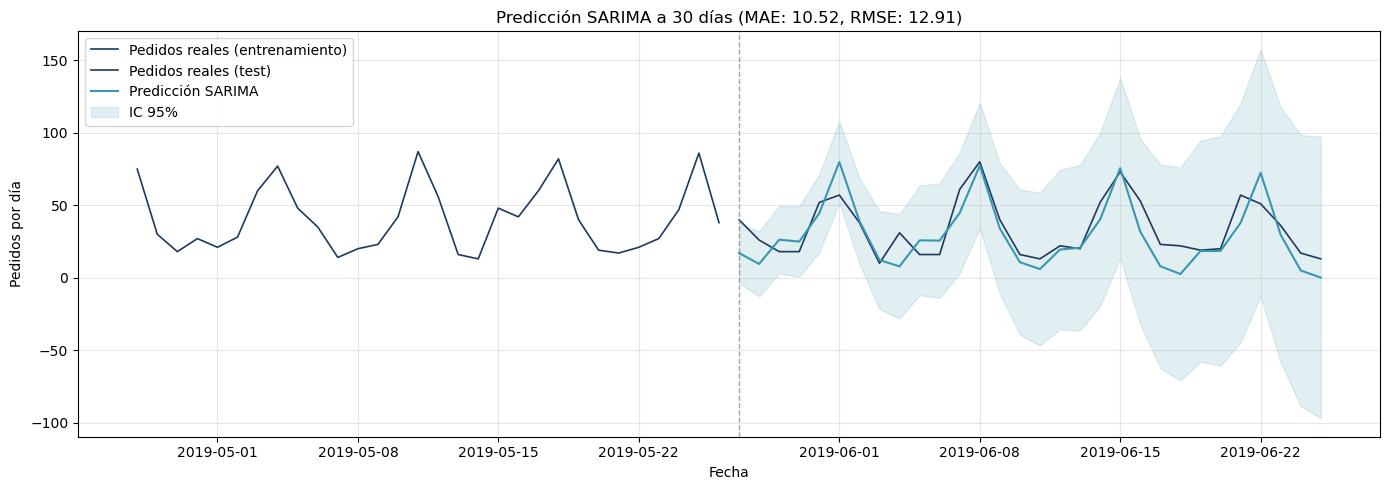


Figura guardada en ..\docs\figura_sarima_prediccion.png


In [30]:
# Entrenamos SARIMA con los datos de train del fold 6
from pmdarima import ARIMA

modelo_sarima_fold = ARIMA(
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    suppress_warnings=True
)
modelo_sarima_fold.fit(train_fold["n_pedidos"])

# Generamos la predicción a 30 días con intervalo de confianza
prediccion_sarima_30, ic_sarima_30 = modelo_sarima_fold.predict(
    n_periods=30, return_conf_int=True, alpha=0.05
)

# Métricas del fold para incluir en el título
mae_sarima = np.abs(test_fold_30["n_pedidos"].values - prediccion_sarima_30).mean()
rmse_sarima = np.sqrt(((test_fold_30["n_pedidos"].values - prediccion_sarima_30) ** 2).mean())

# Construcción de la gráfica
fig, ax = plt.subplots(figsize=(14, 5))

# Contexto: últimos 30 días del entrenamiento
contexto = train_fold.iloc[-30:]
ax.plot(contexto["fecha"], contexto["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, label="Pedidos reales (entrenamiento)")

# Realidad sobre el periodo de test
ax.plot(test_fold_30["fecha"], test_fold_30["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, linestyle="-", label="Pedidos reales (test)")

# Predicción SARIMA
ax.plot(test_fold_30["fecha"], prediccion_sarima_30,
        color="#3896b0", linewidth=1.5, label="Predicción SARIMA")

# Intervalo de confianza al 95%
ax.fill_between(test_fold_30["fecha"], ic_sarima_30[:, 0], ic_sarima_30[:, 1],
                color="#3896b0", alpha=0.15, label="IC 95%")

# Línea vertical separando entrenamiento y test
ax.axvline(x=test_fold_30["fecha"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.7)

ax.set_title(f"Predicción SARIMA a 30 días (MAE: {mae_sarima:.2f}, RMSE: {rmse_sarima:.2f})")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Guardar como PNG para el TFG
ruta_figura = Path("../docs/figura_sarima_prediccion.png")
ruta_figura.parent.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nFigura guardada en {ruta_figura}")

### 9.2. Comparativa Prophet vs SARIMA (escenario corto plazo)

La siguiente gráfica compara las predicciones de ambos modelos en el 
horizonte de 14 días sobre el último fold de la validación cruzada. 
Para Prophet se utiliza el modelo de corto plazo, que incluye 
festivos y los regresores meteorológicos seleccionados (precipitación 
y viento en ventana de servicio). Para SARIMA se utiliza el modelo 
seleccionado por auto_arima, sin regresores externos.

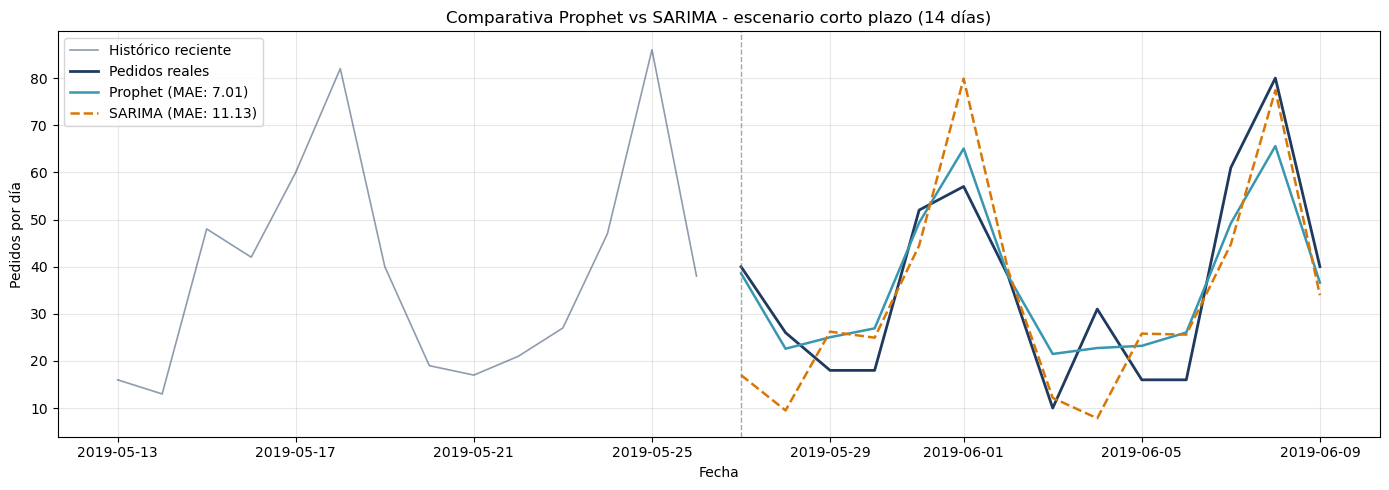


Métricas del fold 6 a 14 días:
  Prophet: MAE 7.01
  SARIMA:  MAE 11.13

Figura guardada en ..\docs\figura_comparativa_corto_plazo.png


In [31]:
# Predicción de Prophet sobre el fold 6 a 14 días
# Usamos el modelo de corto plazo (con festivos + clima reducido)
df_prophet_14 = test_fold_14[["fecha", "precipitacion_total_serv", "viento_medio_serv"]].copy()
df_prophet_14 = df_prophet_14.rename(columns={"fecha": "ds"})

prediccion_prophet_14 = modelo_prophet_corto.predict(df_prophet_14)
yhat_prophet_14 = prediccion_prophet_14["yhat"].values

# Predicción de SARIMA sobre el fold 6 a 14 días
prediccion_sarima_14 = modelo_sarima_fold.predict(n_periods=14)

# Métricas para incluir en el título
mae_prophet_14 = np.abs(test_fold_14["n_pedidos"].values - yhat_prophet_14).mean()
mae_sarima_14_fold = np.abs(test_fold_14["n_pedidos"].values - prediccion_sarima_14).mean()

# Construcción de la gráfica
fig, ax = plt.subplots(figsize=(14, 5))

# Contexto: últimos 14 días del entrenamiento
contexto = train_fold.iloc[-14:]
ax.plot(contexto["fecha"], contexto["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, alpha=0.5, label="Histórico reciente")

# Realidad sobre el periodo de test
ax.plot(test_fold_14["fecha"], test_fold_14["n_pedidos"],
        color="#1f3a5f", linewidth=2, label="Pedidos reales")

# Predicción Prophet
ax.plot(test_fold_14["fecha"], yhat_prophet_14,
        color="#3896b0", linewidth=1.8, label=f"Prophet (MAE: {mae_prophet_14:.2f})")

# Predicción SARIMA
ax.plot(test_fold_14["fecha"], prediccion_sarima_14,
        color="#d97706", linewidth=1.8, linestyle="--",
        label=f"SARIMA (MAE: {mae_sarima_14_fold:.2f})")

# Línea vertical separando entrenamiento y test
ax.axvline(x=test_fold_14["fecha"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("Comparativa Prophet vs SARIMA - escenario corto plazo (14 días)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Guardar PNG para el TFG
ruta_figura = Path("../docs/figura_comparativa_corto_plazo.png")
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nMétricas del fold 6 a 14 días:")
print(f"  Prophet: MAE {mae_prophet_14:.2f}")
print(f"  SARIMA:  MAE {mae_sarima_14_fold:.2f}")
print(f"\nFigura guardada en {ruta_figura}")

### 9.3. Comparativa Prophet vs SARIMA (escenario medio plazo)

La siguiente gráfica compara las predicciones de ambos modelos en el 
horizonte de 30 días sobre el último fold de la validación cruzada. 
Para Prophet se utiliza el modelo de medio plazo, que incluye 
festivos pero sin regresores meteorológicos (dado que las previsiones 
del clima no son fiables más allá de 14 días). Para SARIMA se utiliza 
el modelo seleccionado por auto_arima, sin regresores externos.

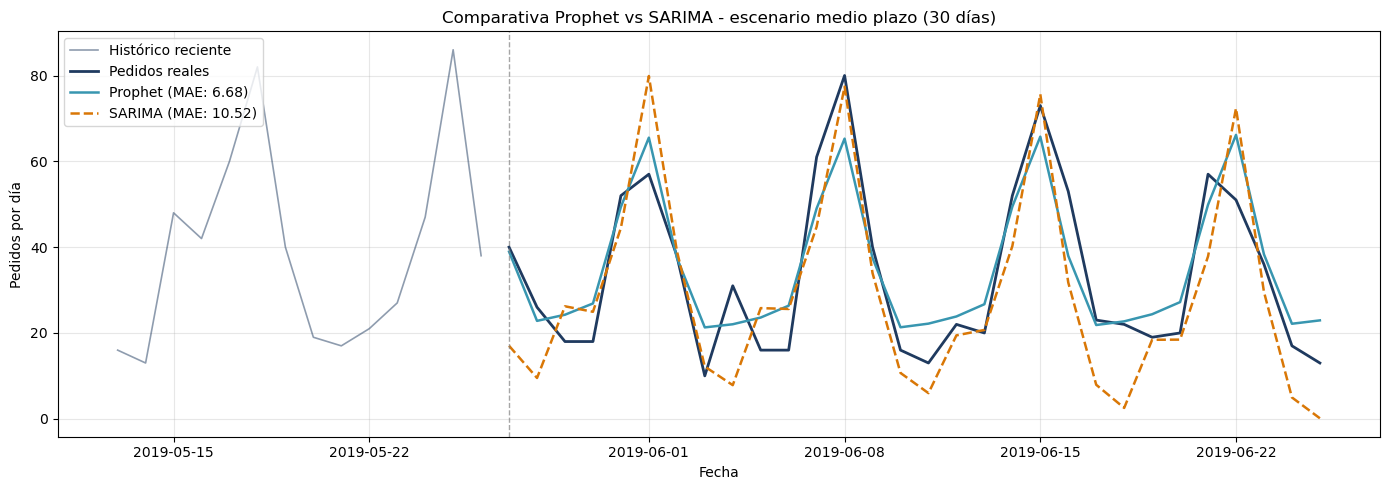


Métricas del fold 6 a 30 días:
  Prophet: MAE 6.68
  SARIMA:  MAE 10.52

Figura guardada en ..\docs\figura_comparativa_medio_plazo.png


In [32]:
# Predicción de Prophet sobre el fold 6 a 30 días
# Usamos el modelo de medio plazo (solo festivos, sin clima)
df_prophet_30 = test_fold_30[["fecha"]].copy()
df_prophet_30 = df_prophet_30.rename(columns={"fecha": "ds"})

prediccion_prophet_30 = modelo_prophet_medio.predict(df_prophet_30)
yhat_prophet_30 = prediccion_prophet_30["yhat"].values

# Predicción de SARIMA ya la tenemos del bloque anterior (prediccion_sarima_30)

# Métricas para el título
mae_prophet_30 = np.abs(test_fold_30["n_pedidos"].values - yhat_prophet_30).mean()
mae_sarima_30_fold = np.abs(test_fold_30["n_pedidos"].values - prediccion_sarima_30).mean()

# Construcción de la gráfica
fig, ax = plt.subplots(figsize=(14, 5))

# Contexto: últimos 14 días del entrenamiento
contexto = train_fold.iloc[-14:]
ax.plot(contexto["fecha"], contexto["n_pedidos"],
        color="#1f3a5f", linewidth=1.2, alpha=0.5, label="Histórico reciente")

# Realidad sobre el periodo de test
ax.plot(test_fold_30["fecha"], test_fold_30["n_pedidos"],
        color="#1f3a5f", linewidth=2, label="Pedidos reales")

# Predicción Prophet (medio plazo)
ax.plot(test_fold_30["fecha"], yhat_prophet_30,
        color="#3896b0", linewidth=1.8, label=f"Prophet (MAE: {mae_prophet_30:.2f})")

# Predicción SARIMA
ax.plot(test_fold_30["fecha"], prediccion_sarima_30,
        color="#d97706", linewidth=1.8, linestyle="--",
        label=f"SARIMA (MAE: {mae_sarima_30_fold:.2f})")

# Línea vertical separando entrenamiento y test
ax.axvline(x=test_fold_30["fecha"].iloc[0], color="gray",
           linestyle="--", linewidth=1, alpha=0.7)

ax.set_title("Comparativa Prophet vs SARIMA - escenario medio plazo (30 días)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pedidos por día")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Guardar PNG para el TFG
ruta_figura = Path("../docs/figura_comparativa_medio_plazo.png")
plt.tight_layout()
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")
plt.show()

print(f"\nMétricas del fold 6 a 30 días:")
print(f"  Prophet: MAE {mae_prophet_30:.2f}")
print(f"  SARIMA:  MAE {mae_sarima_30_fold:.2f}")
print(f"\nFigura guardada en {ruta_figura}")